<a href="https://colab.research.google.com/github/JaoPereira292/Fonte-de-Dados/blob/main/grafico_do_ice_cream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/ice-cream-sales-dataset")

print("caminho para os arquivos conjunto de dados:", path)

Using Colab cache for faster access to the 'ice-cream-sales-dataset' dataset.
caminho para os arquivos conjunto de dados: /kaggle/input/ice-cream-sales-dataset


In [3]:
import pandas as pd
import os

# The path to the dataset was printed in the previous cell
dataset_path = '/kaggle/input/ice-cream-sales-dataset'
ice_cream_df = pd.read_csv(os.path.join(dataset_path, 'Ice Cream.csv'))

display(ice_cream_df.head(5))

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare the data for the model
X = ice_cream_df[['Temperature']] # Independent variable (feature)
y = ice_cream_df['Revenue']       # Dependent variable (target)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Display the model's coefficients
print("Coeficiente (slope):", model.coef_[0])
print("Intercept (y-intercept):", model.intercept_)

Coeficiente (slope): 21.441960923612957
Intercept (y-intercept): 44.296803484425595


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


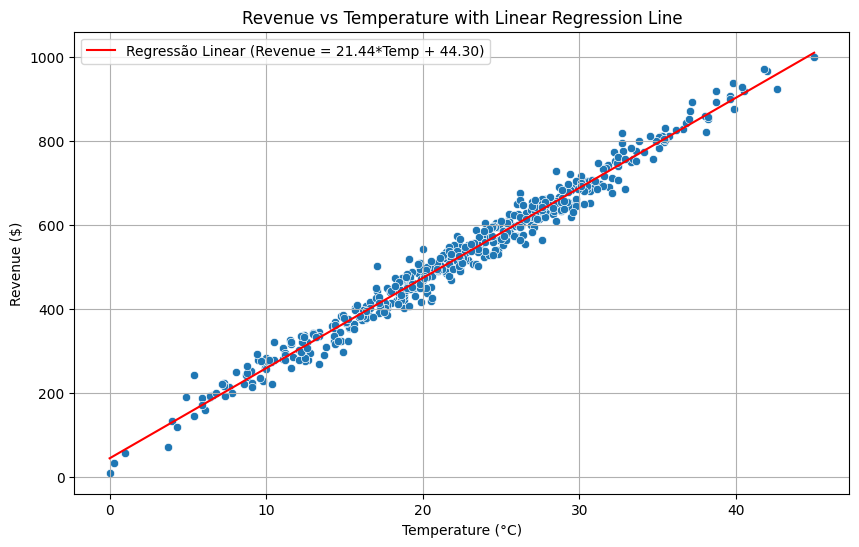

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a scatter plot of Revenue vs Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Revenue', data=ice_cream_df)

# Get the coefficients from the previously trained model (assuming 'model' object exists)
# If the model was not trained in a previous cell, this part will cause an error.
# It's assumed the user has run the cell with the model training code.
slope = model.coef_[0]
intercept = model.intercept_

# Generate points for the regression line
# Use the temperature range from the data for the line
temp_min, temp_max = ice_cream_df['Temperature'].min(), ice_cream_df['Temperature'].max()
temp_range = np.array([temp_min, temp_max]).reshape(-1, 1)
predicted_revenue = model.predict(temp_range)

# Plot the regression line
plt.plot(temp_range, predicted_revenue, color='red', label=f'Regressão Linear (Revenue = {slope:.2f}*Temp + {intercept:.2f})')

plt.title('Revenue vs Temperature with Linear Regression Line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.legend()
plt.show()